<a href="https://colab.research.google.com/github/ahve19/Resampling_methods/blob/main/Resampling_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

By Annelies and Aleksandra

In [80]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from scipy.optimize import minimize


pollution = pd.read_csv('gdrive/My Drive/Colab Notebooks/pollution_cleaneddata.csv')
bird = pd.read_csv('gdrive/My Drive/Colab Notebooks/bird_count.csv')

# Validation approach + Set up

First, we specify a polynomial regression model with degree $p$ that predicts mortality as a function of the average July temp in degrees Farenheit.

In [82]:

random_seed = 1234 # set random seed

X = pollution[['JULT']].values # explanatory variable
y = pollution[['MORT']] # response variable

degrees = [1,2,3,4] # set degrees

# define polynomial model
def poly_model(X, y, p):
  poly = PolynomialFeatures(degree=p)
  X_poly = poly.fit_transform(X)
  lin_reg = LinearRegression()
  lin_reg.fit(X_poly, y)
  return lin_reg


Polynomial models with degree 1 up to 4 where half the data is used for training and half the data is used for testing.

In [83]:
degrees = [1, 2, 3, 4, 5]
results = []

X_train, X_test, y_train, y_test = train_test_split(
    X.reshape(-1, 1), y, test_size=0.5, random_state=random_seed
)

for p in degrees:
  lin_reg = poly_model(X_train, y_train, p)
  poly = PolynomialFeatures(p)
  y_pred = lin_reg.predict(poly.fit_transform(X_test))


  mse_deg = mean_squared_error(y_test, y_pred)
  r2_deg = r2_score(y_test, y_pred)

  results.append(
        {
            "degree": p,
            "mse": mse_deg,
            "r2": r2_deg,
        })


# Convert results list to a Pandas DataFrame
df_results = pd.DataFrame(results)

# Clean up column names for presentation
df_results.columns = ["Degree", "MSE", "R²"]

df_results

,Degree,MSE,R²
0,1,3426.965435,-0.076376
1,2,3152.104050,0.009955
2,3,3406.696111,-0.070010
3,4,3573.791895,-0.122493
4,5,3577.467385,-0.123647


Plotting of the results with the polynomial degree on the x-axis and the MSE on the y-axis

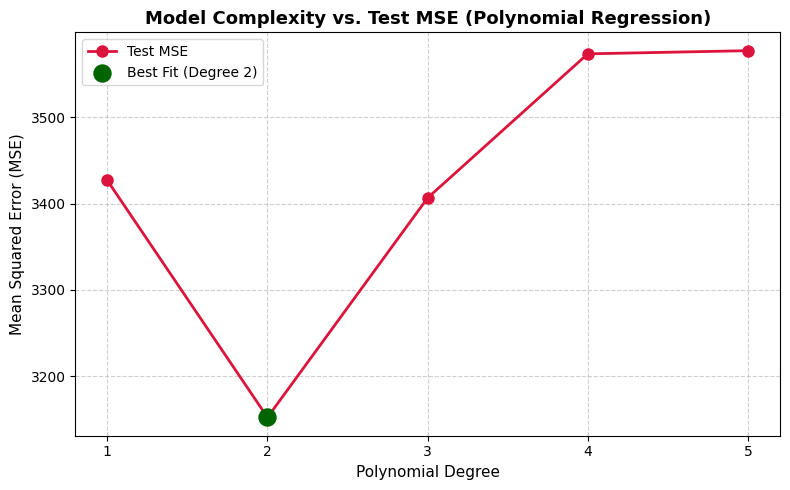

In [84]:
plt.figure(figsize=(8, 5))

# Plot line with markers at each degree
plt.plot(
    df_results['Degree'],
    df_results['MSE'],
    marker='o',
    linestyle='-',
    color='crimson',
    linewidth=2,
    markersize=8,
    label='Test MSE',
)

# Highlight the degree with the minimum MSE
min_mse_row = df_results.loc[df_results['MSE'].idxmin()]
plt.scatter(
    min_mse_row['Degree'],
    min_mse_row['MSE'],
    color='darkgreen',
    s=150,
    zorder=5,
    label=f"Best Fit (Degree {int(min_mse_row['Degree'])})",
)

plt.title(
    'Model Complexity vs. Test MSE (Polynomial Regression)',
    fontsize=13,
    fontweight='bold',
)
plt.xlabel('Polynomial Degree', fontsize=11)
plt.ylabel('Mean Squared Error (MSE)', fontsize=11)
plt.xticks(df_results['Degree'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

From the graph generated above, to minimize the variance of new predictions, a degree of polynomial 2 seems to have the lowest MSE.

We should note that changing the random seed will change how the data is split. Dpending on the random seed, the polynomial degree with the lowest MSE changes as seen below.

In [85]:
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
all_results = []

for seed in seeds:
    # Use seed directly in train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X.reshape(-1, 1), y, test_size=0.5, random_state=seed
    )

    for p in degrees:
      lin_reg = poly_model(X_train, y_train, p)
      poly = PolynomialFeatures(p)
      y_pred = lin_reg.predict(poly.fit_transform(X_test))


      mse_deg = mean_squared_error(y_test, y_pred)
      r2_deg = r2_score(y_test, y_pred)

      all_results.append(
          {
            "seed": seed,
            "degree": p,
            "mse": mean_squared_error(y_test, y_pred),
            "r2": r2_score(y_test, y_pred),
          }
      )

# Combine into a single readable DataFrame
df_all = pd.DataFrame(all_results)

# Pivot table to easily compare MSE across seeds for each degree
mse_pivot = df_all.pivot(index="degree", columns="seed", values="mse")
print("---MSE for each degree across 10 different random seeds---")
print(mse_pivot)

print("---Average MSE for each degree ( from 10 different random seeds)---")
print(mse_pivot.mean(axis = 1))

---MSE for each degree across 10 different random seeds---
seed               1             2            3            4            5   \
degree                                                                       
1         5040.756601   3478.233759  3667.911949  4017.191740  2563.018524   
2         6264.876170   6425.207260  3508.538872  4456.842315  2407.977929   
3         4503.027465   4448.747104  2971.958990  2713.454582  2110.844327   
4        18958.874589   5675.700390  2970.789362  8003.487223  2143.221074   
5       137784.761605  15014.731924  2994.655794  6309.187029  2448.750783   

seed               6            7            8            9            10  
degree                                                                     
1         3747.668835  5080.687024  2929.449947  4716.857745  3084.204120  
2         4266.916605  4513.812841  3128.792506  4532.824707  3197.453043  
3         2828.417875  3704.058797  2927.527952  3986.232326  2578.987079  
4         9064

Above, we see that a polynomial of degree 3 has the lowest average MSE. We can use cross_val_score to compare the average MSE for each degree. As shown below, a polynomial with degree 3 has the lowest average MSE.

In [86]:
for degree in range(1, 6):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    # Calculate Mean Squared Error across 10 folds
    scores = cross_val_score(
        model,
        X.reshape(-1, 1),
        y,
        cv=10,
        scoring="neg_mean_squared_error",
    )
    print(f"Degree {degree} - Average MSE: {-scores.mean():.2f}")

Degree 1 - Average MSE: 3886.66
Degree 2 - Average MSE: 3645.20
Degree 3 - Average MSE: 3104.28
Degree 4 - Average MSE: 3215.78
Degree 5 - Average MSE: 3326.60


# K-fold cross validation

K-fold cross-validation is then considered with $p=2$ and where we hold out $K=3$ sets.

In [87]:
p = 2
k = 3 # number of folds

X = pollution[['JULT']] # explanatory variable
y = pollution['MORT'] # response variable

kf = KFold(n_splits=k, shuffle=True, random_state=123)
mse_scores = []
oof_preds = pd.Series(index=X.index, dtype=float)

for train_index, test_index in kf.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    model = make_pipeline(PolynomialFeatures(degree=p), LinearRegression())
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)
    mse_scores.append(mean_squared_error(Y_test, Y_pred))

cv_mse = np.mean(mse_scores)
print(f"Estimate CV MSE across {k} folds: {cv_mse}")
print(f"Estimate Variance of predictions: {cv_mse/k}")

Estimate CV MSE across 3 folds: 4596.819277006939
Estimate Variance of predictions: 1532.2730923356464


Like before, we can repeat this procedure for 10 different random seeds.

In [88]:
p = 2  # Degree p = 2
k = 3  # 3-fold cross-validation
seeds = range(1, 11)
results = []

for seed in seeds:
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    fold_mses = []

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

        lin_reg = poly_model(X_train, Y_train, p)
        poly = PolynomialFeatures(p)

        y_pred = lin_reg.predict(poly.fit_transform(X_test))

        fold_mses.append(mean_squared_error(Y_test, y_pred))

    cv_mean_mse = np.mean(fold_mses)

    results.append(
        {
            "Seed": seed,
            "Mean CV MSE": cv_mean_mse,
            "Estimate variance of predictions": cv_mean_mse/k,
        }
    )

df_cv = pd.DataFrame(results)
print(df_cv.to_string(index=False))


 Seed  Mean CV MSE  Estimate variance of predictions
    1  5175.994078                       1725.331359
    2  5176.310229                       1725.436743
    3  3513.029877                       1171.009959
    4  3826.803794                       1275.601265
    5  3924.199874                       1308.066625
    6  5740.597705                       1913.532568
    7  3758.749369                       1252.916456
    8  3576.517064                       1192.172355
    9  5723.806750                       1907.935583
   10  3658.313780                       1219.437927


For some of the random seeds there are similar results but for others the variance is much lower. This occurs due to the relatively low fold count (2/3 train and 1/3 test per fold). This is amplifyed by the small sample size meaning both the training and testing are small and one single extreme prediction can impact the variance significantly.

# Bootstrap

We use the Poisson model with maximum likelihood from earlier in the course. Here we have the parameter $\hat{\beta}_1$ estimated as -0.03244.

In [89]:
y = bird['count']
x = bird['yr']

def neg_log_likelihood(params, x, y):
    beta0, beta1 = params
    log_lambda = beta0 + beta1 * x
    lambda_ = np.exp(log_lambda)
    # Omitting sum(log(y!)) because it is constant wrt params
    return np.sum(lambda_ - y * log_lambda)

# Get the years from first count to prevent numeric overflow
x_centered = x - x[0]

# Optimize negative log-likelihood
initial_guess = [0.0, 0.0]
result = minimize(neg_log_likelihood, initial_guess, args=(x_centered, y), method='BFGS')

# Recover parameters on the original scale
beta0_centered, beta1 = result.x
beta0_original = beta0_centered - beta1 * x[0]

print(f"Beta 0: {beta0_original:.5f}")
print(f"Beta 1: {beta1:.5f}")

Beta 0: 67.17924
Beta 1: -0.03244


We want to use the bootstrap to approximate the standard error of the estimated slope parameter above. Below we do 10000 samples to bootstrap.

In [90]:
x_arr = np.array(x)
y_arr = np.array(y)
n_samples = len(y_arr)

# Bootstrap settings
n_bootstraps = 10000
bootstrap_beta1 = []

# Bootstrap loop
for _ in range(n_bootstraps):
    # sample data with replacement
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    x_boot = x_arr[boot_indices]
    y_boot = y_arr[boot_indices]

    # Center years
    x_boot_centered = x_boot - x_arr[0]

    # Refit negative log-likelihood on bootstrap sample
    res = minimize(
        neg_log_likelihood,
        initial_guess,
        args=(x_boot_centered, y_boot),
        method="BFGS",
    )

    # Store slope estimate if optimization converged
    if res.success:
        bootstrap_beta1.append(res.x[1])

bootstrap_beta1 = np.array(bootstrap_beta1)


We can compute the standard error of the estimate of the slope parameter. The standard error is the sample standard deviation of the bootstrap distribution.

In [91]:

# Compute Standard Error
se_beta1 = np.std(bootstrap_beta1, ddof=1)

print(f"Bootstrap Standard Error for Beta 1: {se_beta1:.5f}")
print(
    f"Successful Bootstrap Samples: {len(bootstrap_beta1)} / {n_bootstraps}"
)


Bootstrap Standard Error for Beta 1: 0.03450
Successful Bootstrap Samples: 8309 / 10000


Additionally, a histogram of the boostrap samples for the estimate can be plotted. This demonstrates the distributions and how likely the original estimate was.

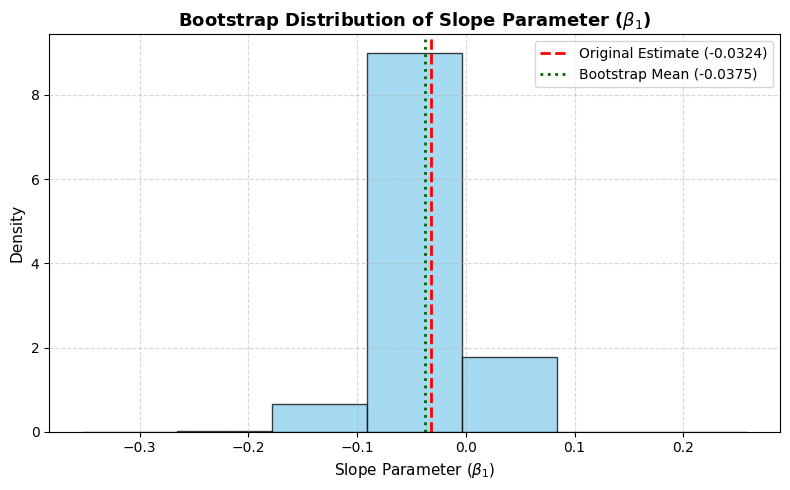

In [92]:

plt.figure(figsize=(8, 5))
plt.hist(
    bootstrap_beta1,
    bins=7,
    color="skyblue",
    edgecolor="black",
    alpha=0.75,
    density=True,
)

# Add reference lines for original point estimate and bootstrap mean
plt.axvline(
    beta1,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Original Estimate ({beta1:.4f})",
)
plt.axvline(
    np.mean(bootstrap_beta1),
    color="darkgreen",
    linestyle=":",
    linewidth=2,
    label=f"Bootstrap Mean ({np.mean(bootstrap_beta1):.4f})",
)

plt.xlabel(r"Slope Parameter ($\beta_1$)", fontsize=11)
plt.ylabel("Density", fontsize=11)
plt.title(
    r"Bootstrap Distribution of Slope Parameter ($\beta_1$)",
    fontsize=13,
    fontweight="bold",
)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()